## DOS Attack Classification
#### Logistic regression, perceptrons, decision tree, and random forest implementation

### Libraries 
* Pandas
* Nummpy
* sklearn

In [3]:
import os
import re
import gzip
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats
from sklearn.model_selection import train_test_split

**->** The function **df_no_high_corr** calculates the correlation matrix between columns and based on that eliminates one of the columns that are highly correlated.\
It ignores all object or category type columns in a data set


In [4]:
def df_no_high_corr(df, threshold=0.5):
# Select only numeric columns
    numdf = df.select_dtypes(include=["int64", "float64"])

    # Compute the absolute correlation matrix
    correlation_matrix = numdf.corr().abs()

    # Mask the lower triangle and diagonal
    mask = np.triu(np.ones(correlation_matrix.shape), k=1)  # k=1 excludes diagonal
    df_upper = pd.DataFrame(correlation_matrix, columns=numdf.columns, index=numdf.columns).where(mask == 1)

    # Identify columns to drop
    to_drop = set()
    for col in df_upper.columns:
        highly_correlated = df_upper[col][df_upper[col] > threshold].index
        to_drop.update(highly_correlated)  # Add correlated columns to the drop set

    # Remove the selected columns from the DataFrame
    df_no_cor = df.drop(columns=to_drop)
    return df_no_cor

**->** The function ***binary_encode_categorical*** is to turn binary categories into o and 1. In this code it is only used for the target column.

In [5]:
def binary_encode_categorical(df):
    """
    Parameters:
    df (pd.DataFrame): The input DataFrame to encode.
    Returns:
    pd.DataFrame: A new DataFrame with binary encoded categorical columns.
    """
    # Select columns with categorical or object dtype
    cat_columns = df.select_dtypes(include=['object', 'category']).columns

    # Initialize the LabelEncoder
    encoder = LabelEncoder()

    # Copy the original DataFrame to avoid modifying the original one
    df_encoded = df.copy()

    # Apply LabelEncoder only to columns with exactly 2 unique categories
    for col in cat_columns:
        if df[col].nunique() == 2:  # Check if the column has exactly 2 unique categories
            # Encode the column to binary (0 or 1)
            df_encoded[col] = encoder.fit_transform(df_encoded[col])
        else:
            ###Do nothing
            df_encoded[col] = df_encoded[col]
            
    return df_encoded

**->** The function ***one_hot_encode_categorical*** Does one hot encoding to categorical variables that have more than 2 category.

In [6]:
def one_hot_encode_categorical(df):
    categorical_df = df.select_dtypes(include=['object', 'category'])

    df_encoded = df.copy() #Copy of the original df

    for col in categorical_df.columns:
        if categorical_df[col].nunique() > 2:  #  one-hot encoding for columns with more than 2 unique categories
            # Perform one-hot encoding and add the resulting columns to the copied DataFrame
            one_hot_encoded = pd.get_dummies(categorical_df[col], prefix=col, drop_first=True)
            df_encoded = pd.concat([df_encoded, one_hot_encoded], axis=1)
            # Drop the original column after encoding
            df_encoded.drop(col, axis=1, inplace=True)
        else:
            # If there are only 2 unique values, keep the original column as is
            df_encoded[col] = df[col]

    # Convert boolean columns to integers (True/False -> 1/0)
    for col in df_encoded.columns:
        if df_encoded[col].dtype == 'bool':
            df_encoded[col] = df_encoded[col].astype(int)

    return df_encoded

**->** The function ***get_columns_with_zeros*** Identifies if the column is a column of only zeroes for values.

In [7]:
def get_columns_with_zeros(df, threshold=1e-6):
    zero_columns = []  # List to store columns with values close to zero
    #df.columns = df.columns.astype(str)
    # Iterate over each column in the DataFrame
    for col in df.columns:
        # Check if all values in the column are within the threshold of zero
        if (df[col].abs() < threshold).all():
            zero_columns.append(col)

    return zero_columns

**->** The function ***get_columns_with_zeros*** Identifies if the column is a column of only zeroes for values.

In [19]:
def train_and_save_model(model, model_name):
    fold_accuracies = []
    for fold, (train_index, test_index) in enumerate(kf.split(X_scaled, y), 1):
        # Split data into training and testing sets
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict and evaluate
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        fold_accuracies.append(accuracy)

        # Save the model for this fold
        joblib.dump(model, f'{model_name}_fold{fold}.pkl')
        print(f'{model_name} - Fold {fold} Accuracy: {accuracy:.4f}')

    # Print average accuracy across folds
    avg_accuracy = np.mean(fold_accuracies)
    print(f'{model_name} - Average Accuracy: {avg_accuracy:.4f}\n')

**->** The function ***train_and_save_model***     """
    Trains the model using cross-validation and saves it with filenames that include the specified suffix.

In [70]:
def train_and_save_model(model, model_name, file_suffix):

    fold_accuracies = []
    for fold, (train_index, test_index) in enumerate(kf.split(X_scaled, y), 1):
        # Split data into training and testing sets
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict and evaluate
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        fold_accuracies.append(accuracy)

        # Save the model for this fold with a unique identifier
        filename = f'{model_name}_{file_suffix}_fold{fold}.pkl'
        joblib.dump(model, filename)
        print(f'{model_name} - Fold {fold} Accuracy: {accuracy:.4f} | Saved as: {filename}')

    # Print average accuracy across folds
    avg_accuracy = np.mean(fold_accuracies)
    print(f'{model_name} - Average Accuracy: {avg_accuracy:.4f}\n')

In [71]:
##Reading the file
def find_file(filename, search_path):
    for root, dirs, files in os.walk(search_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

name_of_file = 'attack_data.csv.gz'
path = find_file(name_of_file, os.path.expanduser('~'))

In [10]:
df = pd.read_csv(path, compression='gzip', encoding='utf-8', on_bad_lines='skip', header=None)

### 1. Preparing the data

In [11]:
####Eliminating columns with high correlation and turning the target variable to number values
df_no_cor1 = df_no_high_corr(df, threshold=0.5)
df_no_cor = binary_encode_categorical(df_no_cor1)

In [13]:
X = df_no_cor.drop(columns=41)  # Data without the target column
y = df_no_cor[41]  # Target

In [14]:
X1 = one_hot_encode_categorical(X) # Does one hot encoding to the categorical variable

In [15]:
X2 = df_no_high_corr(X1, threshold=0.5) #Checks for correlation once again

In [16]:
X2.columns = X2.columns.astype(str) #Turns column names to strings 
z_cols = get_columns_with_zeros(X2, threshold=1e-6) #making sure none of the columns have only zero variables
X3 = X2.drop(columns= z_cols)

In [46]:
y.value_counts(normalize=True) #Checking for imbalance in the data (on the target variable)

41
0    0.513747
1    0.486253
Name: proportion, dtype: float64

##### -> Ready data: Once the columns have been pre prepared we can start training the models
We will be separating the data into 5 folds for cross validation with Kfold

In [81]:
X = X3  # Features (Ensure X3 is defined properly)
y = df_no_cor[41]  # Target

### 2. Training the models

In [120]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize models
logistic_model = LogisticRegression(max_iter=100, random_state=42)
perceptron_model = Perceptron(eta0=0.001 ,max_iter=1000, random_state=42)
decision_tree_model2 = DecisionTreeClassifier(max_depth=2, min_samples_split=10, random_state=42)
decision_tree_model4 = DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42)
random_forest_model3 = RandomForestClassifier(n_estimators=3,max_depth=3, random_state=42)
random_forest_model5 = RandomForestClassifier(n_estimators=5,max_depth=3, random_state=42) # 3 trees for simplicity

kf = KFold(n_splits=5, shuffle=True, random_state=42) #splits up the data sets in 5 folds for cross validation

In [103]:
train_and_save_model(logistic_model, 'logistic_regression','1') #function that does the cross validation and saves each model

logistic_regression - Fold 1 Accuracy: 0.9624 | Saved as: logistic_regression_1_fold1.pkl
logistic_regression - Fold 2 Accuracy: 0.9621 | Saved as: logistic_regression_1_fold2.pkl
logistic_regression - Fold 3 Accuracy: 0.9607 | Saved as: logistic_regression_1_fold3.pkl
logistic_regression - Fold 4 Accuracy: 0.9603 | Saved as: logistic_regression_1_fold4.pkl
logistic_regression - Fold 5 Accuracy: 0.9599 | Saved as: logistic_regression_1_fold5.pkl
logistic_regression - Average Accuracy: 0.9611



In [93]:
train_and_save_model(perceptron_model, 'perceptron','1')

perceptron - Fold 1 Accuracy: 0.9602 | Saved as: perceptron_1_fold1.pkl
perceptron - Fold 2 Accuracy: 0.9616 | Saved as: perceptron_1_fold2.pkl
perceptron - Fold 3 Accuracy: 0.9597 | Saved as: perceptron_1_fold3.pkl
perceptron - Fold 4 Accuracy: 0.9882 | Saved as: perceptron_1_fold4.pkl
perceptron - Fold 5 Accuracy: 0.9583 | Saved as: perceptron_1_fold5.pkl
perceptron - Average Accuracy: 0.9656



In [110]:
train_and_save_model(decision_tree_model2, 'decision_tree','2')

decision_tree - Fold 1 Accuracy: 0.9691 | Saved as: decision_tree_2_fold1.pkl
decision_tree - Fold 2 Accuracy: 0.9691 | Saved as: decision_tree_2_fold2.pkl
decision_tree - Fold 3 Accuracy: 0.9689 | Saved as: decision_tree_2_fold3.pkl
decision_tree - Fold 4 Accuracy: 0.9688 | Saved as: decision_tree_2_fold4.pkl
decision_tree - Fold 5 Accuracy: 0.9691 | Saved as: decision_tree_2_fold5.pkl
decision_tree - Average Accuracy: 0.9690



Visualizing the decission tree of 2 folds

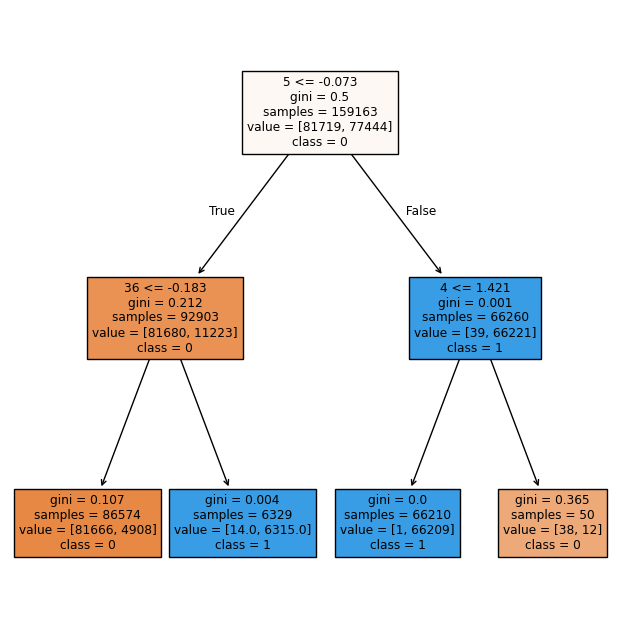

In [116]:
Tree_mode2 = joblib.load('decision_tree_2_fold2.pkl')

# Assuming you have the feature names from the dataset used to train the model
feature_names = X.columns  # Replace with your actual feature names
class_names = Tree_mode2.classes_  # Extract class names from the model

# Plot the decision tree
plt.figure(figsize=(8, 8))
plot_tree(
    Tree_mode2, 
    feature_names=feature_names, 
    class_names=class_names.astype(str),  # Ensure class names are strings
    filled=True
)
plt.show()

In [112]:
train_and_save_model(decision_tree_model4, 'decision_tree', '4')

decision_tree - Fold 1 Accuracy: 0.9810 | Saved as: decision_tree_4_fold1.pkl
decision_tree - Fold 2 Accuracy: 0.9810 | Saved as: decision_tree_4_fold2.pkl
decision_tree - Fold 3 Accuracy: 0.9808 | Saved as: decision_tree_4_fold3.pkl
decision_tree - Fold 4 Accuracy: 0.9815 | Saved as: decision_tree_4_fold4.pkl
decision_tree - Fold 5 Accuracy: 0.9817 | Saved as: decision_tree_4_fold5.pkl
decision_tree - Average Accuracy: 0.9812



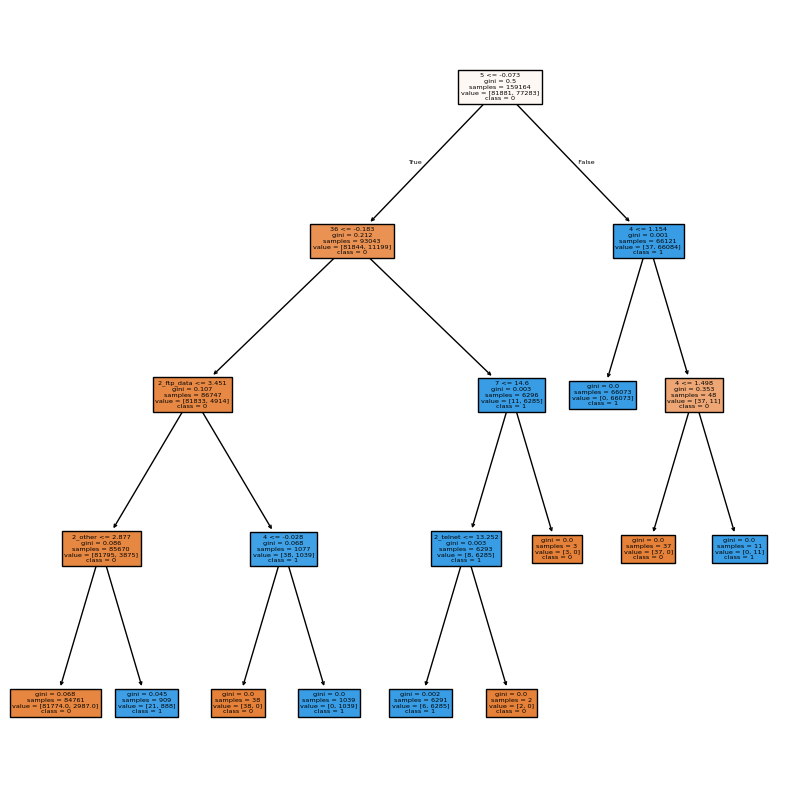

In [113]:
Tree_mode2 = joblib.load('decision_tree_4_fold5.pkl')

# Assuming you have the feature names from the dataset used to train the model
feature_names = X.columns  # Replace with your actual feature names
class_names = Tree_mode2.classes_  # Extract class names from the model

# Plot the decision tree
plt.figure(figsize=(10, 10))
plot_tree(
    Tree_mode2, 
    feature_names=feature_names, 
    class_names=class_names.astype(str),  # Ensure class names are strings
    filled=True
)
plt.show()

In [121]:
train_and_save_model(random_forest_model3, 'random_forest', '3')

random_forest - Fold 1 Accuracy: 0.9611 | Saved as: random_forest_3_fold1.pkl
random_forest - Fold 2 Accuracy: 0.9602 | Saved as: random_forest_3_fold2.pkl
random_forest - Fold 3 Accuracy: 0.9606 | Saved as: random_forest_3_fold3.pkl
random_forest - Fold 4 Accuracy: 0.9602 | Saved as: random_forest_3_fold4.pkl
random_forest - Fold 5 Accuracy: 0.9598 | Saved as: random_forest_3_fold5.pkl
random_forest - Average Accuracy: 0.9604



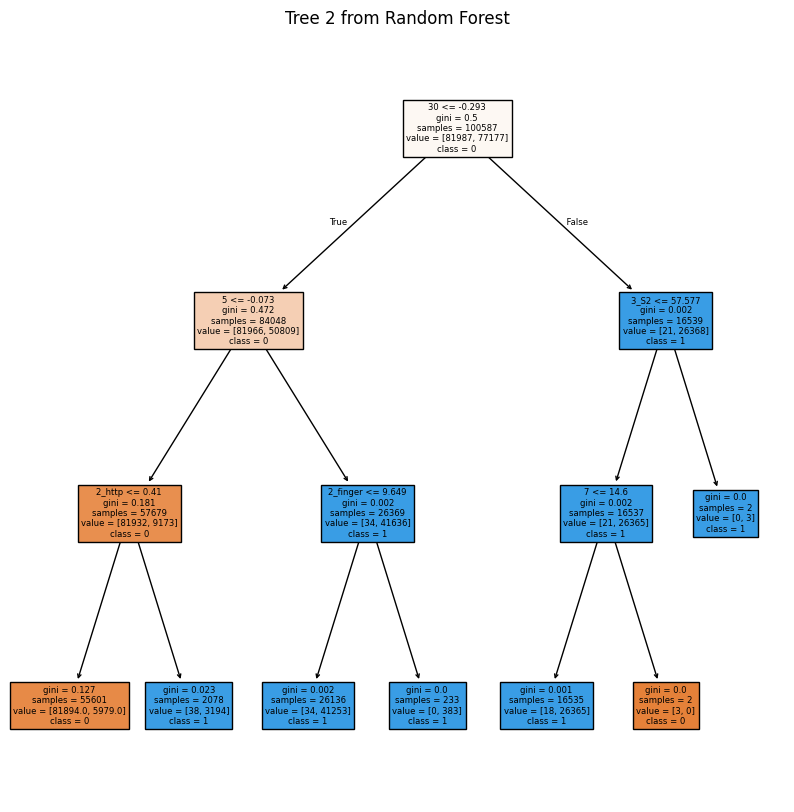

In [124]:
random_forest_model = joblib.load('random_forest_3_fold5.pkl')

# Select a single tree from the Random Forest
# For example, choose the first tree (index 0)
tree_index = 1
single_tree = random_forest_model.estimators_[tree_index]

# Assuming you have feature names from the dataset used to train the model
feature_names = X.columns  # Replace with actual feature names
class_names = random_forest_model.classes_  # Extract class names

# Plot the selected decision tree
plt.figure(figsize=(10, 10))
plot_tree(
    single_tree, 
    feature_names=feature_names, 
    class_names=class_names.astype(str),  # Ensure class names are strings
    filled=True
)
plt.title(f"Tree {tree_index + 1} from Random Forest")
plt.show()

In [125]:
train_and_save_model(random_forest_model5, 'random_forest','5')

random_forest - Fold 1 Accuracy: 0.9653 | Saved as: random_forest_5_fold1.pkl
random_forest - Fold 2 Accuracy: 0.9628 | Saved as: random_forest_5_fold2.pkl
random_forest - Fold 3 Accuracy: 0.9631 | Saved as: random_forest_5_fold3.pkl
random_forest - Fold 4 Accuracy: 0.9661 | Saved as: random_forest_5_fold4.pkl
random_forest - Fold 5 Accuracy: 0.9655 | Saved as: random_forest_5_fold5.pkl
random_forest - Average Accuracy: 0.9646



-> Discussion: Varying the parameters of each model we can get them each to fit better, though we want to prevent overfitting. 

### 3. Stacking
We chose the best model out of each and create a new data set with the purpose of stacking, where we put together the outputs of each of the best model given each algorithm

In [130]:
logistic_model = joblib.load('logistic_regression_1_fold1.pkl')
perceptron_model = joblib.load('perceptron_1_fold4.pkl')
decision_tree_model = joblib.load('decision_tree_4_fold5.pkl')
random_forest_model = joblib.load('random_forest_5_fold4.pkl')

X_scaled = scaler.fit_transform(X)

# Generate model outputs for the new dataset
logistic_outputs = logistic_model.predict(X_scaled)
perceptron_outputs = perceptron_model.predict(X_scaled)
decision_tree_outputs = decision_tree_model.predict(X_scaled)
random_forest_outputs = random_forest_model.predict(X_scaled)

# Construct the new dataset
new_dataset = pd.DataFrame({
    'Logistic_Output': logistic_outputs,
    'Perceptron_Output': perceptron_outputs,
    'DecisionTree_Output': decision_tree_outputs,
    'RandomForest_Output': random_forest_outputs,
    'True_Label': y
})

In [131]:
results = {}
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Test the model
    y_pred = model.predict(X_test)

    # Evaluate the model
    report = classification_report(y_test, y_pred, output_dict=True)
    results[model_name] = report

    print(f"Model: {model_name}")
    print(classification_report(y_test, y_pred))

# Compare model performance
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"The best model on the new dataset is: {best_model_name}")

Model: Linear Regression
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30789
           1       1.00      0.98      0.99     28898

    accuracy                           0.99     59687
   macro avg       0.99      0.99      0.99     59687
weighted avg       0.99      0.99      0.99     59687

Model: Perceptron
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30789
           1       1.00      0.98      0.99     28898

    accuracy                           0.99     59687
   macro avg       0.99      0.99      0.99     59687
weighted avg       0.99      0.99      0.99     59687

Model: Decision Tree
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     30789
           1       1.00      0.98      0.99     28898

    accuracy                           0.99     59687
   macro avg       0.99      0.99      0.99     59687
weighted a

Stacking performs better than the original models 